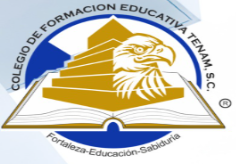

# Actividad Preliminar 2
## Universidad TENAM

**Docente:** DANIEL GONZÁLEZ SCARPULLI  
**Alumno:** Ismael Rufino Grajeda Marin

In [ ]:
% Compatibilidad grafica con octave y jupiter  
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');
% paquete necesario para histeq
pkg load image;

### Ecualización

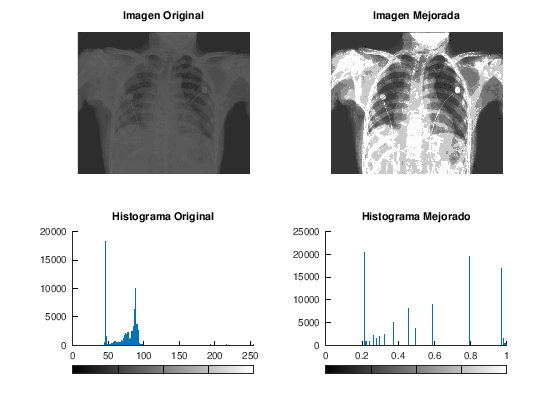

In [23]:

imagen = imread('img/torax1.jpg');

if size(imagen, 3) > 1
 imagen = rgb2gray(imagen);
end
% Aplicar el mejoramiento del histograma
imagen_mejorada = histeq(imagen);
% Mostrar la imagen original y la imagen mejorada
subplot(2, 2, 1);
imshow(imagen);
title('Imagen Original');
subplot(2, 2, 2);
imshow(imagen_mejorada);
title('Imagen Mejorada');
% Graficar los histogramas originales y mejorados
subplot(2, 2, 3);
imhist(imagen);
title('Histograma Original');
subplot(2, 2, 4);
imhist(imagen_mejorada);
title('Histograma Mejorado');

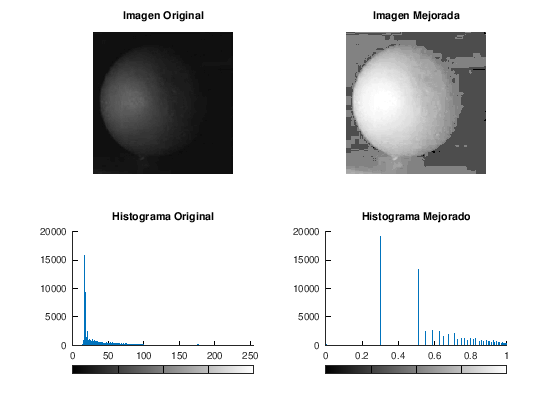

In [24]:
imagen = imread('img/esfera_oscura.jpg');

if size(imagen, 3) > 1
 imagen = rgb2gray(imagen);
end
% Aplicar el mejoramiento del histograma
imagen_mejorada = histeq(imagen);
% Mostrar la imagen original y la imagen mejorada
subplot(2, 2, 1);
imshow(imagen);
title('Imagen Original');
subplot(2, 2, 2);
imshow(imagen_mejorada);
title('Imagen Mejorada');
% Graficar los histogramas originales y mejorados
subplot(2, 2, 3);
imhist(imagen);
title('Histograma Original');
subplot(2, 2, 4);
imhist(imagen_mejorada);
title('Histograma Mejorado');

Observaciones: La ecualización del histograma siempre redistribuye las intensidades para intentar uniformarlas, pero:

Si la imagen tiene baja variabilidad real (por ejemplo, casi todos los píxeles tienen valores muy similares), entonces no hay suficiente información radiométrica para generar contraste significativo.

En esos casos, la ecualización puede:

Amplificar ruido.

Generar artefactos.

Producir una apariencia artificial sin mejorar realmente la información visual.

# Filtrado Pasa altas y pasa bajas

## Pasa bajas

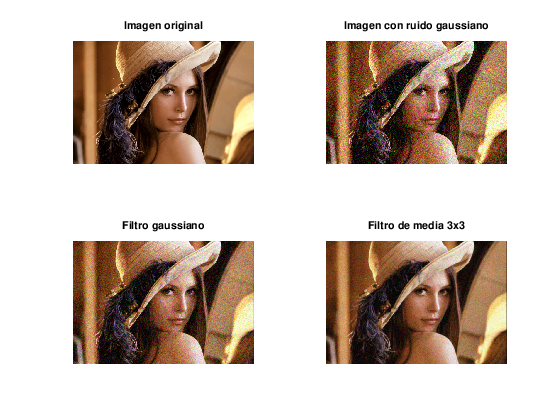

In [30]:
% Cargar la imagen
imagen = imread('img/Lena.jpg');
% Se agrega ruido gaussiano a la imagen
imagen_ruido = imnoise(imagen,'gaussian');
% Convertir la imagen a escala de grises (si es necesario)
imagen_grises = rgb2gray(imagen);
% Aplicar filtros pasa bajas
filtro_media = fspecial('average', [3, 3]);
filtro_gaussiano=fspecial('gaussian');
imagen_filtrada1 = imfilter(imagen_ruido, filtro_gaussiano);
imagen_filtrada2 = imfilter(imagen_ruido, filtro_media);
% Mostrar la imagen original, imagen con ruido y la imagen filtrada
subplot(2, 2, 1);
imshow(imagen);
title('Imagen original');
subplot(2, 2, 2);
imshow(imagen_ruido);
title('Imagen con ruido gaussiano');
subplot(2, 2, 3);
imshow(imagen_filtrada1);
title('Filtro gaussiano');
subplot(2, 2, 4);
imshow(imagen_filtrada2);
title('Filtro de media 3x3');

#### 2.- con mascara de 8x8 

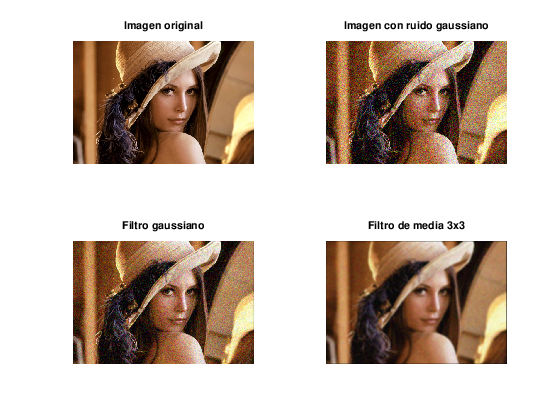

In [31]:
% Cargar la imagen
imagen = imread('img/Lena.jpg');
% Se agrega ruido gaussiano a la imagen
imagen_ruido = imnoise(imagen,'gaussian');
% Convertir la imagen a escala de grises (si es necesario)
imagen_grises = rgb2gray(imagen);
% Aplicar filtros pasa bajas
filtro_media = fspecial('average', [8, 8]);
filtro_gaussiano=fspecial('gaussian');
imagen_filtrada1 = imfilter(imagen_ruido, filtro_gaussiano);
imagen_filtrada2 = imfilter(imagen_ruido, filtro_media);
% Mostrar la imagen original, imagen con ruido y la imagen filtrada
subplot(2, 2, 1);
imshow(imagen);
title('Imagen original');
subplot(2, 2, 2);
imshow(imagen_ruido);
title('Imagen con ruido gaussiano');
subplot(2, 2, 3);
imshow(imagen_filtrada1);
title('Filtro gaussiano');
subplot(2, 2, 4);
imshow(imagen_filtrada2);
title('Filtro de media 3x3');

In [ ]:
Filtro de la media:
Es un filtro lineal que reemplaza cada píxel por el promedio de sus vecinos. Reduce el ruido,
pero suaviza en exceso la imagen y degrada los bordes, ya que todos los píxeles del kernel tienen el mismo peso.

Filtro gaussiano:
También es un filtro lineal de suavizado, pero asigna mayor peso a los píxeles cercanos al centro según
una distribución gaussiana. Produce un desenfoque más natural, preserva mejor la estructura de la 
imagen y es más eficaz para reducir ruido gaussiano.

## Pasa altas

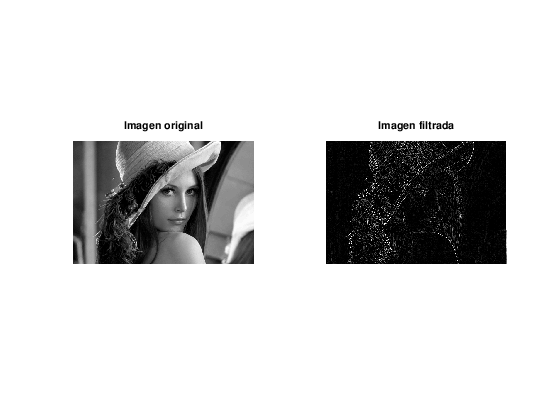

In [33]:
% Cargar la imagen
imagen = imread('img/Lena.jpg');
% Convertir la imagen a escala de grises (si es necesario)
imagen_grises = rgb2gray(imagen);
% Aplicar el filtro pasa altas simple
filtro_pasa_altas = [-1 -1 -1; -1 8 -1; -1 -1 -1];
imagen_filtrada = imfilter(imagen_grises, filtro_pasa_altas);
% Mostrar la imagen original y la imagen filtrada
subplot(1, 2, 1);imshow(imagen_grises);
title('Imagen original');
subplot(1, 2, 2);
imshow(imagen_filtrada);
title('Imagen filtrada');

A = 2
w = 17


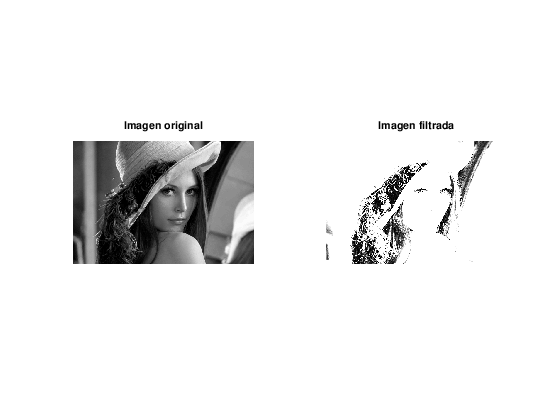

In [38]:
% Cargar la imagen
imagen = imread('img/Lena.jpg');
% Convertir la imagen a escala de grises (si es necesario)
imagen_grises = rgb2gray(imagen);
% Aplicar el filtro pasa altas simple con énfasis en frecuencias altas
A=2
w= 9*A-1
filtro_pasa_altas = [-1 -1 -1; -1 w -1; -1 -1 -1];
imagen_filtrada = imfilter(imagen_grises, filtro_pasa_altas);
% Mostrar la imagen original y la imagen filtrada
subplot(1, 2, 1);
imshow(imagen_grises);
title('Imagen original');
subplot(1, 2, 2);
imshow(imagen_filtrada);
title('Imagen filtrada');

El filtro pasa altas resalta los bordes y detalles finos de la imagen.

Las zonas homogéneas (bajas frecuencias) se atenúan o se ven más oscuras.

Se incrementa el contraste en transiciones bruscas de intensidad.

Puede hacer más visible el ruido, ya que el ruido también es alta frecuencia.

Al aumentar el valor central (énfasis en altas frecuencias), la imagen se vuelve más nítida pero puede aparecer sobresaturación y artefactos.

## Operaciones binarias

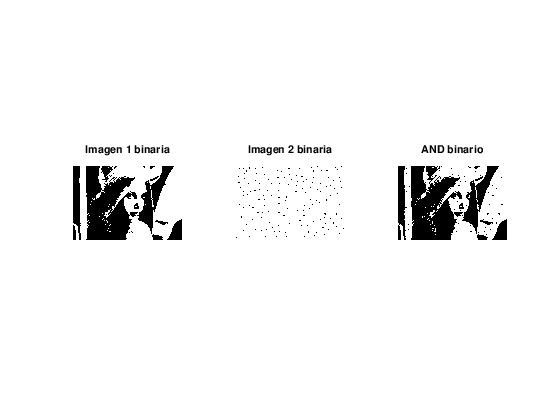

In [41]:
imagen1 = imread('img/Lena.jpg');
imagen2 = imread('img/puntos_negros.jpg');
% Verificar que las imágenes tengan las mismas dimensiones
if size(imagen1) == size(imagen2)
    % Convertir las imágenes a escala de grises (si es necesario)
    if size(imagen1, 3) > 1
        imagen1 = rgb2gray(imagen1);
    end
    if size(imagen2, 3) > 1
        imagen2 = rgb2gray(imagen2);
    end
    % Convertir las imágenes a imágenes binarias (umbralización)
    umbral1 = graythresh(imagen1);
    imagen1_bin = im2bw(imagen1, umbral1);
    umbral2 = graythresh(imagen2);
    imagen2_bin = im2bw(imagen2, umbral2);
    % Aplicar la operación de AND binario
    imagen_and = imagen1_bin & imagen2_bin;
    % Mostrar las imágenes y el resultado
    subplot(1, 3, 1);
    imshow(imagen1_bin);
    title('Imagen 1 binaria');
    subplot(1, 3, 2);
    imshow(imagen2_bin);
    title('Imagen 2 binaria');
    subplot(1, 3, 3);
    imshow(imagen_and);
    title('AND binario');
else
    disp('Las imágenes deben tener las mismas dimensiones.');
end

In [ ]:
La imagen resultante es una superposicion de ambas imagenes en los bits 0's gracias al operador  and 

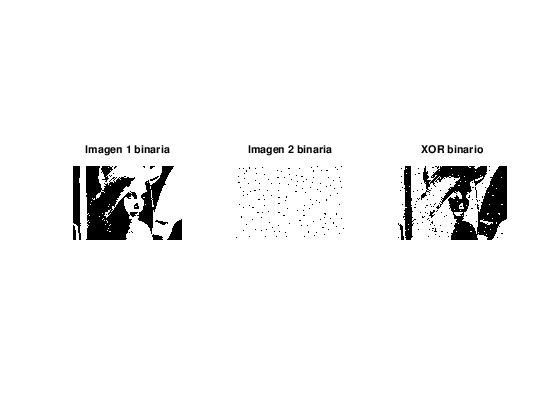

In [44]:
% Cargar las dos imágenes
imagen1 = imread('img/Lena.jpg');
imagen2 = imread('img/puntos_negros.jpg');
% Verificar que las imágenes tengan las mismas dimensiones
if isequal(size(imagen1), size(imagen2))
% Convertir las imágenes a escala de grises (si es necesario)
if size(imagen1, 3) > 1imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
imagen2 = rgb2gray(imagen2);
end
% Convertir las imágenes a imágenes binarias (umbralización)
umbral1 = graythresh(imagen1);
imagen1_bin = im2bw(imagen1, umbral1);
umbral2 = graythresh(imagen2);
imagen2_bin = im2bw(imagen2, umbral2);
% Aplicar la operación XOR binaria
imagen_xor = xor(imagen1_bin, imagen2_bin);
% Mostrar las imágenes y el resultado
subplot(1, 3, 1);
imshow(imagen1_bin);
title('Imagen 1 binaria');
subplot(1, 3, 2);
imshow(imagen2_bin);
title('Imagen 2 binaria');
subplot(1, 3, 3);
imshow(imagen_xor);
title('XOR binario');
else
disp('Las imágenes deben tener las mismas dimensiones.');
end

In [ ]:
Gracias a la operacion xor, resaltan las diferencias.

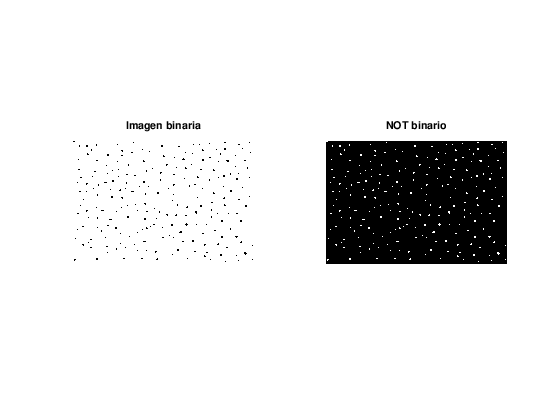

In [47]:
% Cargar la imagen
imagen = imread('img/puntos_negros.jpg');
% Convertir la imagen a escala de grises (si es necesario)
if size(imagen, 3) > 1
imagen = rgb2gray(imagen);
end
% Convertir la imagen a imagen binaria (umbralización)
umbral = graythresh(imagen);
imagen_bin = im2bw(imagen, umbral);
% Aplicar la operación NOT binaria
imagen_not = ~imagen_bin;
% Mostrar la imagen binaria original y la imagen NOT
subplot(1, 2, 1);
imshow(imagen_bin);
title('Imagen binaria');
subplot(1, 2, 2);
imshow(imagen_not);
title('NOT binario');

In [ ]:
L imagen resultante es inversa a la original